# **언어 모델 활용_모델 Fine_Tuning_실습**

## 1.환경준비

### (1) 라이브러리 설치 및 로딩

In [1]:
!pip install datasets peft accelerate -q

* 설치 후 세션 다시 시작

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch

from transformers import AutoTokenizer, AutoModelForSequenceClassification, Trainer, TrainingArguments, EarlyStoppingCallback
from datasets import load_dataset, Dataset

from sklearn.model_selection import train_test_split
from sklearn.metrics import *
from sklearn.preprocessing import LabelEncoder

from peft import get_peft_model, LoraConfig, TaskType

from warnings import filterwarnings
FutureWarning
filterwarnings('ignore')

c:\Users\USER\anaconda3\envs\aivle_pytorch\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


* 함수 생성

In [37]:
# 검증셋 평가 함수
def evaluate(val_ds, model, device, tokenizer):
    # 입력 데이터셋 토크나이징 (attention_mask 포함)
    inputs = tokenizer(val_ds['text'], return_tensors="pt", padding=True,
                       truncation=True, max_length=128
    )
    inputs = {key: value.to(device) for key, value in inputs.items()}  # 입력 텐서를 동일한 디바이스로 이동

    # 모델을 지정된 디바이스로 이동
    model = model.to(device)

    with torch.no_grad():  # 평가 과정에서 기울기 계산 비활성화
        outputs = model(**inputs)  # attention_mask를 포함해 입력

    # 예측 및 확률 계산
    probabilities = outputs.logits.softmax(dim=1)

    # probabilities가 GPU에 있을 경우에만 CPU로 이동
    if probabilities.is_cuda:
        probabilities = probabilities.cpu().detach().numpy()
    else:
        probabilities = probabilities.detach().numpy()

    pred = np.argmax(probabilities, axis=1)

    # GPU 메모리에서 필요 없는 텐서 제거 및 캐시 정리
    del inputs
    torch.cuda.empty_cache()

    return pred, probabilities

In [38]:
def predict(text, model, tokenizer):
    # 모델을 CPU로 이동
    model = model.to("cpu")

    # 입력 문장 토크나이징 → CPU 텐서로 생성
    inputs = tokenizer(text, return_tensors="pt", truncation=True, padding=True)

    # 모델 예측 (no_grad로 메모리 절약)
    with torch.no_grad():
        outputs = model(**inputs)

    # 확률 계산
    logits = outputs.logits
    probabilities = torch.softmax(logits, dim=1)

    # 예측 클래스
    pred = torch.argmax(probabilities, dim=-1).item()

    return pred, probabilities


### (2) 구글드라이브 연결

In [39]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [40]:
path = '/content/drive/MyDrive/KT\ AIVLE\ School/langchain/'

### (3) 데이터 로딩

In [41]:
data = pd.read_csv('https://raw.githubusercontent.com/DA4BAM/dataset/refs/heads/master/naver_news_title.csv')
data.rename(columns = {'titles' : 'text', 'category' : 'label'}, inplace = True)
data.drop_duplicates(subset=['text'], inplace=True)
data = data.sample(5000)
data.head()

,text,label
532,일간 조 억 날린 악몽 산업계 물류마비발 셧다운 공포,Social
451,진 월 일 전방 사단 신병교육대 입대,Social
21537,양낙규의 갈 길 멀다 남은 세 과제는,Politics
50792,한국 반도체 잡겠다며 토요타 소니 뭉쳤다 파급력은,World
9963,아메리칸 뮤직 어워드 년 연속 수상 팝 다양성 확대,Culture


* y 분포 확인하기

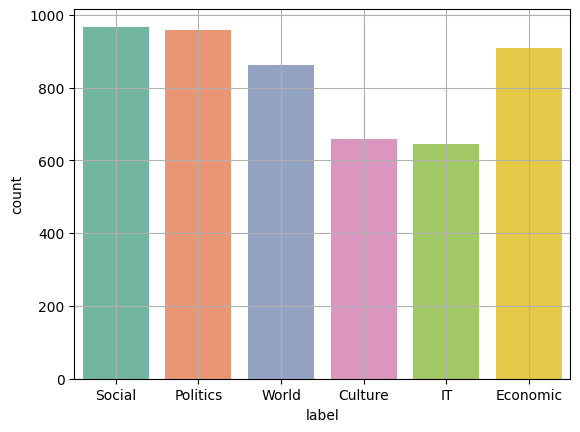

In [42]:
sns.countplot(x='label', data = data, palette='Set2')
plt.grid()
plt.show()

* label 에 대한 정수 인코딩

In [43]:
le = LabelEncoder()
data['label'] = le.fit_transform(data['label'])
data.head()

,text,label
532,일간 조 억 날린 악몽 산업계 물류마비발 셧다운 공포,4
451,진 월 일 전방 사단 신병교육대 입대,4
21537,양낙규의 갈 길 멀다 남은 세 과제는,3
50792,한국 반도체 잡겠다며 토요타 소니 뭉쳤다 파급력은,5
9963,아메리칸 뮤직 어워드 년 연속 수상 팝 다양성 확대,0


In [44]:
label_list = list(le.classes_)
label_list

['Culture', 'Economic', 'IT', 'Politics', 'Social', 'World']

### (4) GPU 설정
* 파이토치를 위한 설정

In [45]:
# GPU 설정
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cuda')

## 2.데이터 준비

### (1) Dataset 만들기 : train, val

In [46]:
train, val = train_test_split(data, test_size=0.3, random_state=100)

In [47]:
# df로 부터 텐서 데이터셋 만들기
train_ts = Dataset.from_pandas(train)
val_ts = Dataset.from_pandas(val)

In [48]:
train_ts[:3]

{'text': [' 자막뉴스  코로나 대위기 맞이한 중국   심상치 않은 확산세',
  '수능 날  복도 감독관의 하루는 이랬습니다    대 교사의 고교 일기 ',
  '아르헨티나  공 때문에 사우디에 졌다'],
 'label': [5, 0, 2],
 '__index_level_0__': [51661, 12824, 54550]}

### (2) 토크나이징

In [49]:
# 모델과 토크나이저 불러오기
model_name = "distilbert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(model_name)

In [50]:
# 토큰화 함수 생성 및 작업
def preprocess_function(data):
    return tokenizer(data['text'], truncation=True, padding=True)

train_ts = train_ts.map(preprocess_function, batched=True)
val_ts = val_ts.map(preprocess_function, batched=True)

Map:   0%|          | 0/3500 [00:00<?, ? examples/s]

Map:   0%|          | 0/1500 [00:00<?, ? examples/s]

## 3.Fine-Tuning

### (1) 사전학습 모델 준비

In [51]:
# 1. 모델 로드
n = 6
model = AutoModelForSequenceClassification.from_pretrained(model_name,
                                                           num_labels = n).to(device)

Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


### (2) 학습 설정

In [52]:
training_args = TrainingArguments(
    output_dir = './results',
    eval_strategy = "epoch",
    save_strategy = "epoch",
    learning_rate = 2e-5,               # 작은 학습률
    per_device_train_batch_size = 32,   # 학습 배치 사이즈
    per_device_eval_batch_size = 32,
    num_train_epochs = 5,               # 에폭 수
    weight_decay = 0.02,                # weight decay
    load_best_model_at_end = True,      # earlystopping 사용하기 위해 필요
    logging_dir ='./logs',
    logging_steps = 10,
    report_to="tensorboard",
)

In [53]:
# Trainer 설정
trainer = Trainer(
    model=model,                         # 학습할 모델
    args=training_args,                  # TrainingArguments
    train_dataset = train_ts,
    eval_dataset = val_ts,
    tokenizer = tokenizer,
    callbacks = [EarlyStoppingCallback(early_stopping_patience=3)], # 조기 종료
)

### (3) 학습
* 위 코드 그대로

In [54]:
trainer.train()

Epoch,Training Loss,Validation Loss
1,1.684900,1.690653
2,1.625000,1.665247
3,1.581100,1.632427
4,1.594400,1.566167
5,1.511200,1.550665


TrainOutput(global_step=550, training_loss=1.6173678796941584, metrics={'train_runtime': 309.583, 'train_samples_per_second': 56.528, 'train_steps_per_second': 1.777, 'total_flos': 538771956607440.0, 'train_loss': 1.6173678796941584, 'epoch': 5.0})

In [55]:
eval_results = trainer.evaluate()
print(f"Evaluation results: {eval_results}")

Evaluation results: {'eval_loss': 1.5506646633148193, 'eval_runtime': 3.5426, 'eval_samples_per_second': 423.422, 'eval_steps_per_second': 13.267, 'epoch': 5.0}


### (4) 모델 사용

In [56]:
text = "IT기업 카카오"
predicted_class, probabilities = predict(text, model, tokenizer)

print(f"예측된 클래스: {predicted_class}")
print(f"예측된 클래스 이름: {label_list[predicted_class]}")
print(f"클래스별 확률: {probabilities}")

예측된 클래스: 2
예측된 클래스 이름: IT
클래스별 확률: tensor([[0.2137, 0.1376, 0.2924, 0.0342, 0.0400, 0.2820]])


### (5) 모델 검증평가

In [59]:
predictions_output = trainer.predict(val_ts)
logits = predictions_output.predictions

# logits가 torch.Tensor인 경우 CPU로 옮기기
if isinstance(logits, torch.Tensor):
    logits = logits.detach().cpu().numpy()

pred = np.argmax(logits, axis=1)

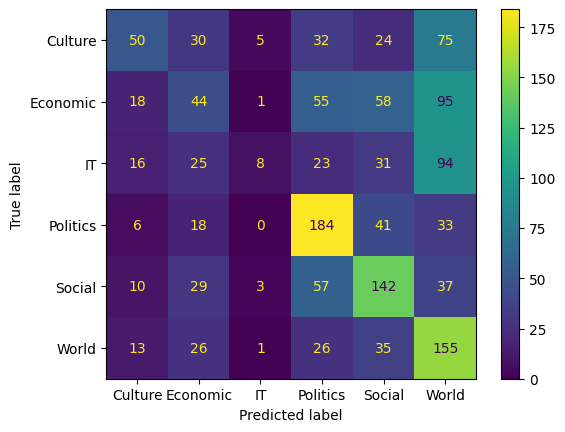

              precision    recall  f1-score   support

     Culture       0.44      0.23      0.30       216
    Economic       0.26      0.16      0.20       271
          IT       0.44      0.04      0.07       197
    Politics       0.49      0.65      0.56       282
      Social       0.43      0.51      0.47       278
       World       0.32      0.61      0.42       256

    accuracy                           0.39      1500
   macro avg       0.40      0.37      0.34      1500
weighted avg       0.39      0.39      0.35      1500



In [60]:
from sklearn.metrics import ConfusionMatrixDisplay
disp = ConfusionMatrixDisplay(confusion_matrix(val_ts['label'], pred), display_labels = label_list)
disp.plot()
plt.show()

print(classification_report(val_ts['label'], pred, target_names = label_list))